In [1]:
import json
import kagglehub
import pandas as pd
from tqdm import tqdm
from pathlib import Path
from ast import literal_eval
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report

from open_video_summary.adapters.llm import OllamaAdapter
from open_video_summary.core.segmenter.prompts import VideoSegmenterPrompts

def show_results(df_results: pd.DataFrame):
    # Calculate classification metrics
    report = classification_report(df_results['class'], df_results['prediction'], output_dict=True)
    metrics_df = pd.DataFrame(report).transpose()

    # Print precision, recall, and F1-score
    print(metrics_df[['precision', 'recall', 'f1-score']])

    # Plot precision, recall, and F1-score
    metrics_df = metrics_df[:-3]  # Exclude 'accuracy', 'macro avg', and 'weighted avg'
    metrics_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(10, 6))
    plt.title('Precision, Recall, and F1-Score per Class')
    plt.xlabel('Class')
    plt.ylabel('Score')
    plt.xticks(rotation=45)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

/home/leo/phd/repos/open-video-summary/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Text Classification

## text-classification-documentation

In [5]:
dataset_path = Path(kagglehub.dataset_download("tanishqdublish/text-classification-documentation", force_download=True))

destination = Path("../data/datasets/text-classification-documentation")
destination.mkdir(parents=True, exist_ok=True)

for file in dataset_path.iterdir():
    print(file)
    if file.is_file():
        print(file.name)
        file.rename(destination / file.name)

dataset_path = Path(kagglehub.dataset_download("saurabhshahane/ecommerce-text-classification"))
destination = Path("../data/datasets/ecommerce-text-classification")
destination.mkdir(parents=True, exist_ok=True)

for file in dataset_path.iterdir():
    print(file)
    if file.is_file():
        print(file.name)
        file.rename(destination / file.name)

100%|██████████| 1.85M/1.85M [00:01<00:00, 1.08MB/s]

Extracting files...


/home/leo/.cache/kagglehub/datasets/tanishqdublish/text-classification-documentation/versions/1/df_file.csv
df_file.csv
/home/leo/.cache/kagglehub/datasets/saurabhshahane/ecommerce-text-classification/versions/76/ecommerceDataset.csv
ecommerceDataset.csv


In [2]:
df = pd.read_csv("../data/datasets/text-classification-documentation/df_file.csv")
topics = {
    "0": "Politics",
    "1": "Sport",
    "2": "Technology",
    "3": "Entertainment",
    "4": "Business",
}

df = df.rename(columns={"Text": "content", "Label": "topic"})
df = df.sample(frac=1)
df.head()

,content,topic
1237,EU software patent law faces axe\n \n The Euro...,2
1940,Mystery surrounds new Yukos owner\n \n The fat...,4
1479,Help for indies in download sales\n \n A campa...,3
1730,Novartis hits acquisition trail\n \n Swiss dru...,4
2064,Parmalat to return to stockmarket\n \n Parmala...,4


In [3]:
results_path = "../data/datasets/text-classification-documentation/results.csv"

prompts_template = VideoSegmenterPrompts()
llm_adapter = OllamaAdapter()

with open(results_path, "w") as f:
    f.write("index,class,prediction\n")

for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Classifying content"):
    prompt = prompts_template.classify_subtopic.format(
        content=row["content"], topics=topics
    )

    topics_str = llm_adapter.generate_pattern(
        prompt=prompt,
        pattern="(\{.*?\})",
        options={"format": "json", "temperature": 0.2},
    )
    cluster_topic = literal_eval(topics_str)
    prediction, _ = cluster_topic.popitem()

    with open(results_path, "a") as f:
        f.write(f"{index},{row['topic']},{int(prediction)}\n")

Classifying content: 100%|██████████| 2225/2225 [1:29:15<00:00,  2.41s/it]


              precision    recall  f1-score
0              0.926941  0.973621  0.949708
1              0.996094  0.998043  0.997067
2              0.923885  0.877805  0.900256
3              0.885057  0.997409  0.937881
4              0.973856  0.876471  0.922601
accuracy       0.943820  0.943820  0.943820
macro avg      0.941167  0.944670  0.941502
weighted avg   0.945759  0.943820  0.943407


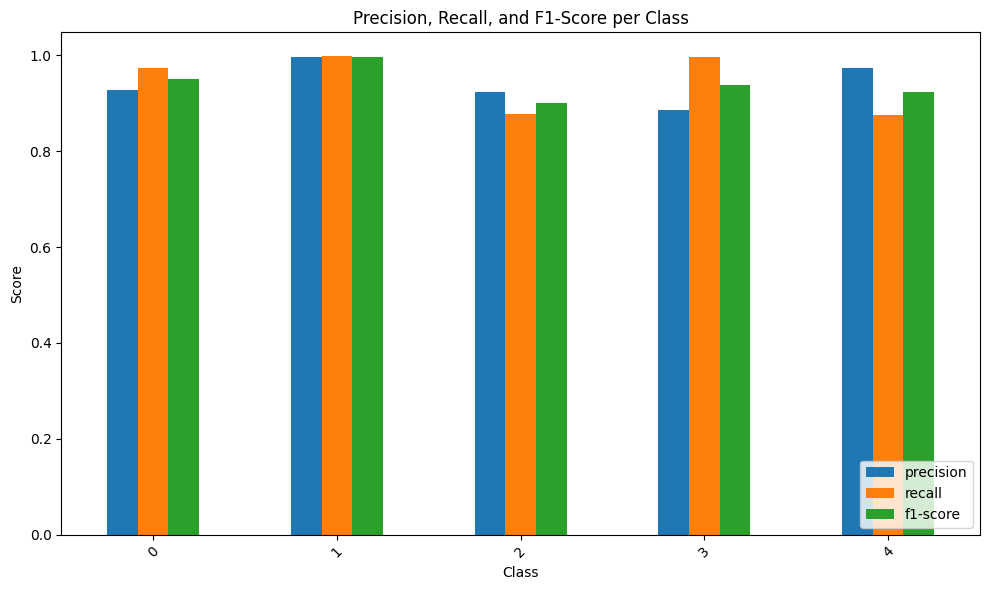

In [ ]:
results_path = "../data/datasets/text-classification-documentation/results.csv"

df_results = pd.read_csv(results_path)
show_results(df_results)

## ecommerceDataset

In [2]:
df = pd.read_csv("../data/datasets/ecommerce-text-classification/ecommerceDataset.csv", header=None, names=["Label", "Text"])
topics = {
    "0": "Books",
    "1": "Household",
    "2": "Clothing & Accessories",
    "3": "Electronics",
}

df = df.rename(columns={"Text": "content", "Label": "topic"})
df["topic"] = df["topic"].map({v: k for k, v in topics.items()})
df = df.sample(frac=1)
print(len(df))
df.head()

50425


,topic,content
9843,1,"Milton Meal Combi Plastic Lunch Box Set, Grey ..."
38031,2,YaYa Cafe Mothers Day Cute Funny Baby Loading ...
38633,2,Phenovo Colorful Enamel Beaded Beads Eyeglass ...
35312,2,Menjestic Mens Casual/Formal Blazer/3 Colours ...
16466,1,Magic Self Cleaning Microfiber Flat Mop and Bu...


In [3]:
results_path = "../data/datasets/ecommerce-text-classification/results.csv"

df_results = pd.read_csv(results_path)
df_results.set_index("index", inplace=True)

df = df[~df.index.isin(df_results.index)]
print(len(df))
df.head()

13154


,topic,content
38633,2,Phenovo Colorful Enamel Beaded Beads Eyeglass ...
30888,0,Moral Stories Talking Cave & Other Stories (Cl...
509,1,"Freelance PVC Shower Mat - 28""x15"", Transparen..."
1767,1,JS Home Decor Sheesham Wood Foldable Patio Din...
25417,0,"Blood Sport About the Author Dick Francis, (19..."


In [4]:
prompts_template = VideoSegmenterPrompts()
llm_adapter = OllamaAdapter()

# with open(results_path, "w") as f:
#     f.write("index,class,prediction\n")

for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Classifying content"):
    prompt = prompts_template.classify_subtopic.format(
        content=row["content"], topics=topics
    )

    topics_str = llm_adapter.generate_pattern(
        prompt=prompt,
        pattern="(\{.*?\})",
        options={"format": "json", "temperature": 0.2},
    )
    cluster_topic = literal_eval(topics_str)
    prediction, _ = cluster_topic.popitem()

    with open(results_path, "a") as f:
        f.write(f"{index},{row['topic']},{int(prediction)}\n")

Classifying content: 100%|██████████| 13154/13154 [6:59:23<00:00,  1.91s/it]  


class
1    19313
0    11820
3    10621
2     8671
Name: count, dtype: int64
              precision    recall  f1-score
0              0.796716  0.931726  0.858948
1              0.978442  0.524051  0.682537
2              0.768955  0.989505  0.865399
3              0.651941  0.926749  0.765426
6              0.000000  0.000000  0.000000
accuracy       0.784472  0.784472  0.784472
macro avg      0.639211  0.674406  0.634462
weighted avg   0.831050  0.784472  0.772793


/home/leo/phd/repos/open-video-summary/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/leo/phd/repos/open-video-summary/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/leo/phd/repos/open-video-summary/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

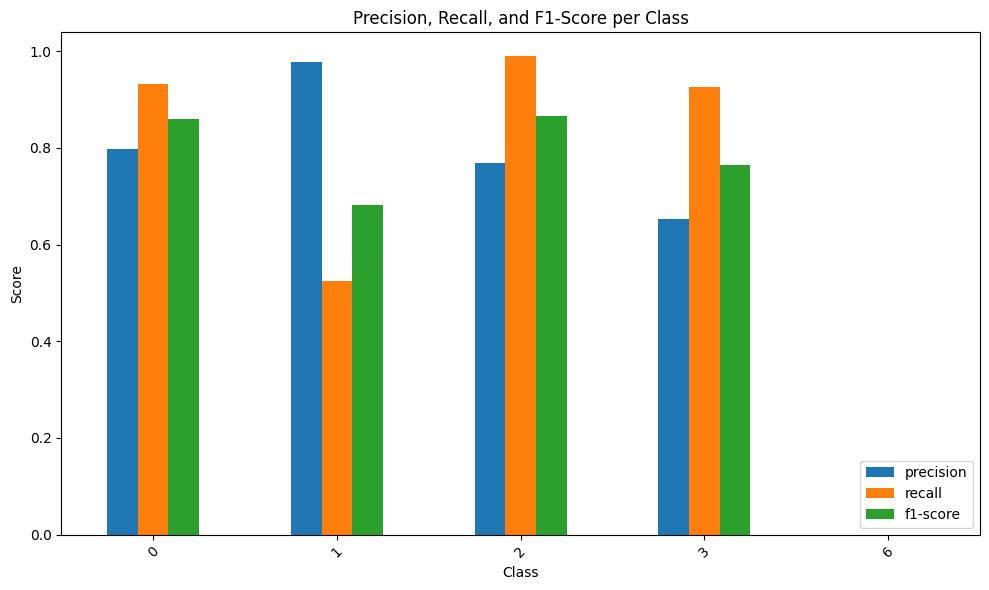

In [5]:
df_results = pd.read_csv(results_path)

print(df_results['class'].value_counts())

show_results(df_results)

## HSMVideoSumm processed

In [57]:
df = pd.read_csv("../data/datasets/hsmvideosumm/hsmvideosumm_processed.csv", sep=";")
topics = {
    "0": "objetivo",
    "1": "subjetivo",
}
df["topic"] = df["subjetividade"].map({v: k for k, v in topics.items()})
df = df[["topic", "content"]]
df = df.sample(frac=1)
df.head()

,topic,content
69,0,"A mina Córrego do Feijão fica em Brumadinho, a..."
62,0,Apesar da Vale ter divulgado que em janeiro de...
98,1,"Meghan Markle falou da magia que é virar mãe, ..."
107,0,"Meghan deu à luz em casa, uma tradição da famí..."
26,1,"No final da tarde, em nova entrevista perto da..."


In [58]:
results_path = "../data/datasets/hsmvideosumm/results_processed.csv"
with open(results_path, "w") as f:
    f.write("index,class,prediction\n")

prompts_template = VideoSegmenterPrompts()
llm_adapter = OllamaAdapter()

for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Classifying content"):
    prompt = prompts_template.classify_subtopic.format(
        content=row["content"], topics=topics
    )

    topics_str = llm_adapter.generate_pattern(
        prompt=prompt,
        pattern="(\{.*?\})",
        options={"format": "json", "temperature": 0.2},
    )
    cluster_topic = literal_eval(topics_str)
    prediction, _ = cluster_topic.popitem()

    with open(results_path, "a") as f:
        f.write(f"{index},{row['topic']},{int(prediction)}\n")

Classifying content: 100%|██████████| 137/137 [16:12<00:00,  7.10s/it]


class
0    106
1     31
Name: count, dtype: int64
              precision    recall  f1-score
0              0.785185  1.000000  0.879668
1              1.000000  0.064516  0.121212
accuracy       0.788321  0.788321  0.788321
macro avg      0.892593  0.532258  0.500440
weighted avg   0.833793  0.788321  0.708047


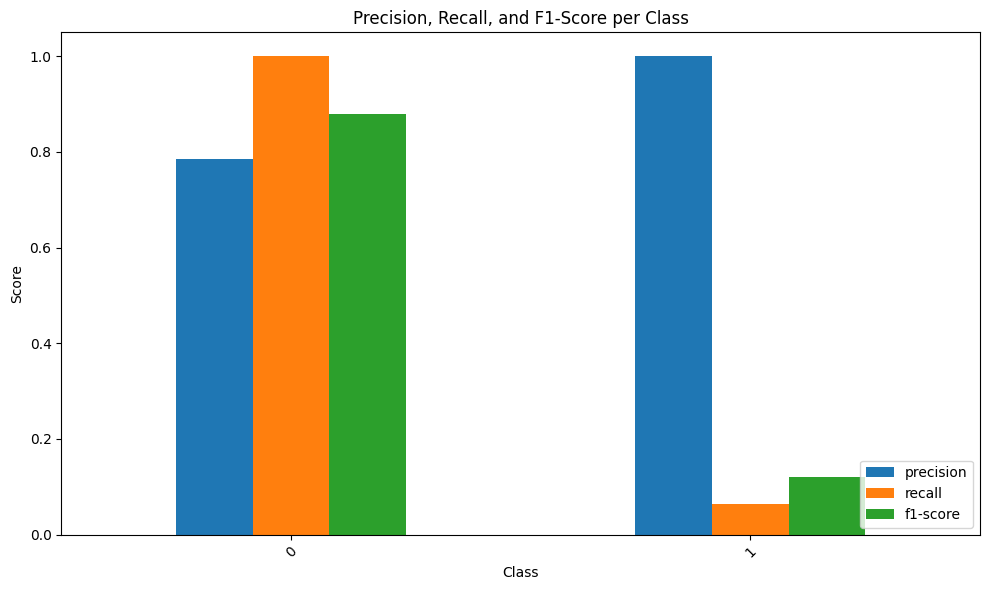

In [59]:
df_results = pd.read_csv(results_path)

print(df_results['class'].value_counts())

show_results(df_results)

## HSMVideoSumm groundtruth

In [44]:
data = []
for file_path in Path("../data/datasets/hsmvideosumm").rglob("*.json"):
    data.extend(json.load(open(file_path, "r")))
df = pd.DataFrame(data)

values_remap = {
    "Neutro": "Neutro",
    "Neutro - sem faces": "Neutro",
    "Entrevista": "Entrevista",
    "Opinião de repórter": "Opinião de repórter",
    "Opinião de repórter/entrevista": "Opinião de repórter",
}
df["topic"] = df["class"].map(values_remap)

topics = {
    "0": "Neutro",
    "1": "Entrevista",
    "2": "Opinião de repórter",
}
df["topic"] = df["topic"].map({v: k for k, v in topics.items()})

df = df[["topic", "content"]]
df = df.sample(frac=1)
df.head()

,topic,content
73,0,"Segundo a mineradora, funcionários trabalhavam..."
36,0,A parte da catedral mais castigada pelas chama...
94,2,Eu conversei agora há pouco com engenheiros de...
19,0,"No geral, seis ministros da comitiva brasileir..."
2,0,"No salão oval da Casa Branca, Bolsonaro disse ..."


In [45]:
results_path = "../data/datasets/hsmvideosumm/results_groundtruth.csv"
with open(results_path, "w") as f:
    f.write("index,class,prediction\n")

prompts_template = VideoSegmenterPrompts()
llm_adapter = OllamaAdapter()

for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Classifying content"):
    prompt = prompts_template.classify_subtopic.format(
        content=row["content"], topics=topics
    )

    topics_str = llm_adapter.generate_pattern(
        prompt=prompt,
        pattern="(\{.*?\})",
        options={"format": "json", "temperature": 0.2},
    )
    cluster_topic = literal_eval(topics_str)
    prediction, _ = cluster_topic.popitem()

    with open(results_path, "a") as f:
        f.write(f"{index},{row['topic']},{int(prediction)}\n")

Classifying content: 100%|██████████| 137/137 [07:57<00:00,  3.48s/it]


class
0    106
1     23
2      8
Name: count, dtype: int64
              precision    recall  f1-score
0              0.800000  0.943396  0.865801
1              1.000000  0.086957  0.160000
2              0.300000  0.375000  0.333333
accuracy       0.766423  0.766423  0.766423
macro avg      0.700000  0.468451  0.453045
weighted avg   0.804380  0.766423  0.716216


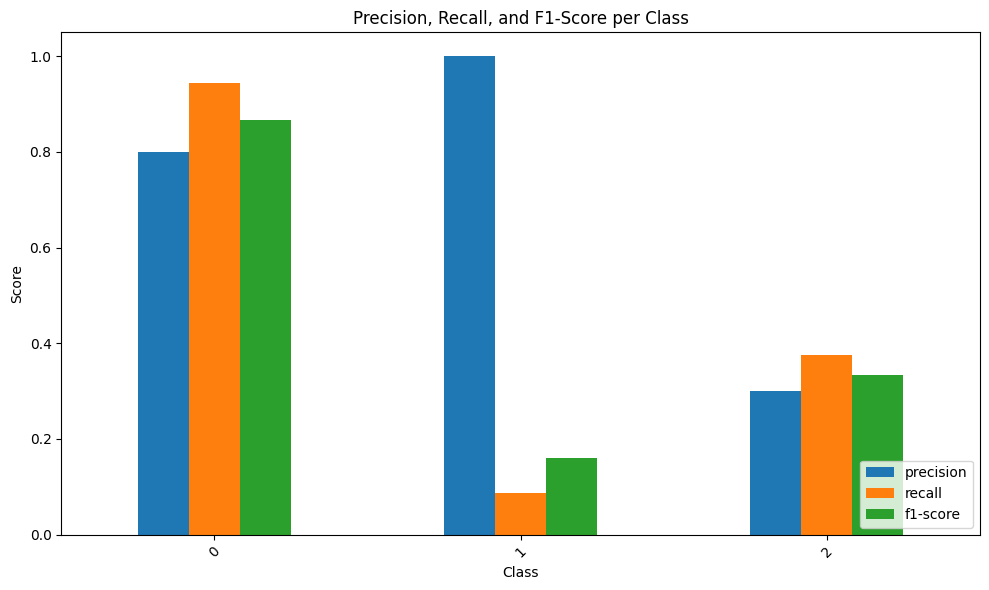

In [46]:
df_results = pd.read_csv(results_path)

print(df_results['class'].value_counts())

show_results(df_results)

# Subtopic generation

In [10]:
prompt = """Evaluate the quality of the subtopics generated for a video transcription. Rate the list of subtopics on four dimensions on a scale from 1 (worst) to 5 (best):

1. Relevance: How well the subtopics list match the actual semantic content in transcript.
Ensures the subtopics are grounded in the source material, not hallucinated.
Score 1 (worst): Unrelated or misleading.    
Score 5 (best): Perfectly matches the content, no extraneous concepts.
    
2. Specificity: Whether the subtopics list are at an appropriate level of detail, not too broad, not too narrow.
Broad topics lose nuance; overly specific topics fragment coherence.
Score 1 (worst): Too vague or too hyper-specific.
Score 5 (best): Accurately scoped.

3. Coverage: How well the subtopics list capture the main ideas of the video, without omitting key points.
Prevents missing critical information that affects the meaning.
Score 1 (worst): Misses most important concepts.
Score 5 (best): Includes all key elements.

4. Distinctiveness: How well the subtopics list are differentiated from each other.
Distinct subtopics improve diversity and avoid repetition.
Score 1 (worst): Nearly identical subtopics.
Score 5 (best): Subtopics are clearly different from each other .

Video transcription:
{video_transcription}

Subtopics:
{subtopics}


Your output should be a JSON object with the following structure:
{{
    "relevance": <score from 1 to 5>,
    "specificity": <score from 1 to 5>,
    "coverage": <score from 1 to 5>,
    "distinctiveness": <score from 1 to 5>
}}

"""

In [18]:
from open_video_summary.parsers.video import VideoLoader

videos = VideoLoader.load_videos_from_json("../data/processed/bebe_real.json")

data = []
for video in videos:
    print(f"Evaluating video: {video.name}")

    transcription = " ".join(s.content for s in video.segments)
    prompt_filled = prompt.format(
        video_transcription=transcription,
        subtopics="\n".join(video.topics)
    )
    llm_judge_adapter = OllamaAdapter(model="gpt-oss:20b")
    
    topics_str = llm_judge_adapter.generate_pattern(
        prompt=prompt_filled,
        pattern="(\{.*?\})",
        options={"format": "json", "temperature": 0.2},
    )
    evaluation = literal_eval(topics_str)
    data.append((video, evaluation))

Evaluating video: jornal_nacional
{
    "relevance": 4,
    "specificity": 4,
    "coverage": 5,
    "distinctiveness": 4
}
Evaluating video: jornal_da_band
{
    "relevance": 3,
    "specificity": 4,
    "coverage": 5,
    "distinctiveness": 4
}
Evaluating video: jornal_da_record
{
    "relevance": 4,
    "specificity": 3,
    "coverage": 4,
    "distinctiveness": 2
}


In [19]:
# GPT-oss
data

[(Video(name='jornal_nacional', path='/home/leo/phd/repos/open-video-summary/data/raw/bebe_real/jornal_nacional.mp4', topics=['Apresentação do filho de Harry e Meghan Markle', 'Reação da multidão à chegada do bebê', 'Primeira aparição pública do bebê real', 'Estilo discreto da apresentação do bebê', 'Sentimentos de Meghan Markle sobre ser mãe', 'Personalidade calma e doce do bebê', 'Nome completo do bebê real: Archie Harrison Mountbatten-Windsor', 'Visita da Rainha Elizabeth II ao recém-nascido', 'Especulações sobre a aparência física do bebê', 'Mudanças na aparência dos bebês e seus pais'], segments=[VideoSegment(content='O Príncipe Harry e a duquesa Meghan Markle apresentaram hoje o filho recém-nascido. A primeira aparição de Harry foi aos olhos de todos. Uma multidão se aglomerou em frente ao hospital.', start=0.7, end=12.3, order=0, video_topic='Apresentação do filho de Harry e Meghan Markle', global_topic='', video_path='/home/leo/phd/repos/open-video-summary/data/raw/bebe_real/jo

In [ ]:
# Deepseek
data

[(Video(name='jornal_nacional', path='/home/leo/phd/repos/open-video-summary/data/raw/bebe_real/jornal_nacional.mp4', topics=['Apresentação do filho de Harry e Meghan Markle', 'Reação da multidão à chegada do bebê', 'Primeira aparição pública do bebê real', 'Estilo discreto da apresentação do bebê', 'Sentimentos de Meghan Markle sobre ser mãe', 'Personalidade calma e doce do bebê', 'Nome completo do bebê real: Archie Harrison Mountbatten-Windsor', 'Visita da Rainha Elizabeth II ao recém-nascido', 'Especulações sobre a aparência física do bebê', 'Mudanças na aparência dos bebês e seus pais'], segments=[VideoSegment(content='O Príncipe Harry e a duquesa Meghan Markle apresentaram hoje o filho recém-nascido. A primeira aparição de Harry foi aos olhos de todos. Uma multidão se aglomerou em frente ao hospital.', start=0.7, end=12.3, order=0, video_topic='Apresentação do filho de Harry e Meghan Markle', global_topic='', video_path='/home/leo/phd/repos/open-video-summary/data/raw/bebe_real/jo